# Customer Churn Prediction Using Support Vector Machine (SVM)

## Introduction

This notebook focuses on developing a machine learning model to predict customer churn using the **Support Vector Machine (SVM)** algorithm.

The cleaned Telco Customer Churn dataset prepared during the data cleaning and exploratory data analysis stage will be used for model development. The categorical features will be encoded, numerical features will be scaled, and the data will be divided into training and testing sets.

Different SVM kernels and hyperparameters will be evaluated to identify a suitable model configuration. The final model will be evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix.


### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#### What is GridSearchCV?
- GridSearchCV is a technique from Scikit-learn used to find the best combination of model hyperparameters.
- For SVM, important hyperparameters include:
    - C
    - kernel
    - gamma
      
#### ColumnTransformer

ColumnTransformer is used to apply different preprocessing steps to different types of columns. For example, numerical columns can be scaled, while categorical columns can be encoded at the same time.

#### Pipeline

Pipeline combines preprocessing steps and the machine learning model into a single workflow. It automatically applies the required preprocessing to the data before making predictions, so the same steps do not need to be written separately during deployment.

#### ROC-AUC Score
- ROC-AUC (Receiver Operating Characteristic – Area Under the Curve) measures how well a classification model distinguishes between two classes.
    - Range: 0 to 1
    - 0.5: Random classification
    - Higher score: Better ability to distinguish between the classes
- In our project, it measures how well the SVM distinguishes between customers who churn and customers who do not churn.

### Loading the cleaned dataset

In [2]:
data = pd.read_csv(r"Data/Telco Customer Dataset Cleaned.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.shape

(7043, 21)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Separate Features and Target

In [5]:
X = data.drop(columns=["customerID", "Churn"])
y = data["Churn"]

In [6]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [7]:
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: str

### Encode the Target Variable 

In [8]:
le = LabelEncoder()

In [9]:
y = le.fit_transform(y)
y

array([0, 0, 1, ..., 0, 1, 0], shape=(7043,))

### Splitting the data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.25,7707.70
6227,Male,0,No,No,2,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),46.05,80.35
4673,Female,1,No,No,25,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,102.80,2660.20
2710,Female,0,Yes,No,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.40,482.80


In [12]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,Female,0,Yes,Yes,49,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,87.20,4345.00
4439,Male,0,Yes,Yes,28,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.30,487.95
3857,Male,0,No,No,5,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.65,93.55
4758,Female,0,No,No,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.70,1051.90


In [13]:
y_train

array([0, 0, 0, ..., 1, 0, 0], shape=(5634,))

In [14]:
y_test

array([0, 0, 0, ..., 0, 0, 0], shape=(1409,))

### Feature Preprocessing using Column Transformer

In [15]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
numerical_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [17]:
numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [18]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

- 'num' → Name given to the numerical preprocessing step.
- 'cat' → Name given to the categorical preprocessing step.
- handle_unknown='ignore' → Prevents errors if a new/unseen category appears in the test or new data.

In [20]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Create the SVM Pipeline

In [21]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC())
])
svm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

### Train the model

In [22]:
svm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

### Make predictions

In [23]:
y_pred = svm_pipeline.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

### Evaluate the basic SVM

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7913413768630234
Precision: 0.6418439716312057
Recall: 0.4839572192513369
F1 Score: 0.551829268292683


### Baseline SVM Model Evaluation

The baseline SVM model achieved an accuracy of 79.13%, with a precision of 64.18%, recall of 48.40%, and F1-score of 55.18%.

While the model correctly classifies a reasonable proportion of customers overall, its recall indicates that it identifies less than half of the customers who actually churn. Therefore, further model improvement through kernel comparison and hyperparameter tuning will be explored.

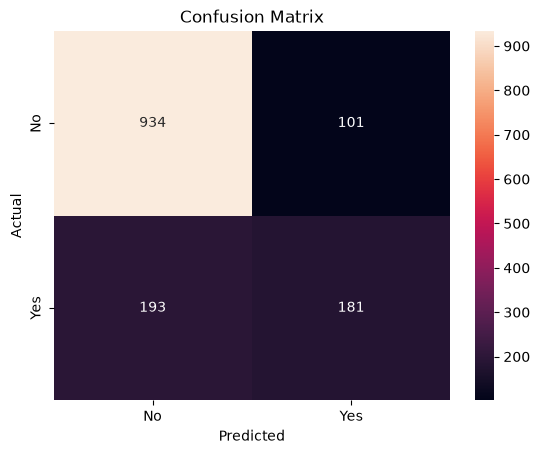

In [25]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

- Actual churners = 193 + 181 = 374
- Correctly identified churners = 181
- Recall = 181 / (181 + 193)
       ≈ 48.40%
- So the model identified 181 out of 374 actual churners, while 193 churners were missed.
- Your baseline SVM is doing much better at identifying non-churners than churners. That's why the overall accuracy is 79.13%, while the churn recall is only 48.40%.
- This gives us a clear reason to continue with kernel comparison and hyperparameter tuning and see whether we can improve the model's performance, particularly its ability to identify churners.

### Test different kernals

In [26]:
kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('svm', SVC(kernel=kernel))
    ])
    
    model.fit(X_train, y_train)
    
    y_pred_kernel = model.predict(X_test)
    
    print(f"\nKernel: {kernel}")
    print("Accuracy:", accuracy_score(y_test, y_pred_kernel))
    print("Precision:", precision_score(y_test, y_pred_kernel))
    print("Recall:", recall_score(y_test, y_pred_kernel))
    print("F1 Score:", f1_score(y_test, y_pred_kernel))


Kernel: linear
Accuracy: 0.7877927608232789
Precision: 0.6175548589341693
Recall: 0.5267379679144385
F1 Score: 0.5685425685425686

Kernel: rbf
Accuracy: 0.7913413768630234
Precision: 0.6418439716312057
Recall: 0.4839572192513369
F1 Score: 0.551829268292683

Kernel: poly
Accuracy: 0.7885024840312278
Precision: 0.6301369863013698
Recall: 0.4919786096256685
F1 Score: 0.5525525525525525


### SVM Kernel Comparison

- Three SVM kernels — Linear, RBF, and Polynomial — were evaluated using the same preprocessing and train-test data.
- The Linear kernel achieved an accuracy of 78.78%, precision of 61.76%, recall of 52.67%, and F1-score of 56.85%.
- The RBF kernel achieved an accuracy of 79.13%, precision of 64.18%, recall of 48.40%, and F1-score of 55.18%.
- The Polynomial kernel achieved an accuracy of 78.85%, precision of 63.01%, recall of 49.20%, and F1-score of 55.26%.
- The results show that the three kernels have relatively similar performance, with differences across the evaluation metrics. Therefore, hyperparameter tuning will be performed to identify a suitable SVM configuration.

### Hyperparameter Tuning

**What is Gamma in SVM?**
- Gamma (γ) controls how far the influence of a single training data point reaches when creating the decision boundary.
- It is mainly important for RBF and Polynomial kernels.
    - Low gamma → each data point has a wider influence → smoother, simpler decision boundary.
    - High gamma → each data point has a narrower influence → more complex, detailed decision boundary.
- There are two methods to calculate gamma value automatically : gamma="scale" and gamma="auto".
  
**gamma='scale'** 
- Takes the feature variance into account.
- Adjusts gamma according to the dataset.
- It is the default setting for SVC.

**gamma='auto'**
- Does not consider feature variance.
- Uses only the number of features.

  | Setting         | Meaning                                                                            | Formula                      |
| --------------- | ---------------------------------------------------------------------------------- | ---------------------------- |
| `gamma='scale'` | Calculates gamma using the number of features **and the variance of the features** | `1 / (n_features × X.var())` |
| `gamma='auto'`  | Calculates gamma using **only the number of features**                             | `1 / n_features`             |


In [27]:
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto']
}

In [28]:
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [29]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto'], 'svm__kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=

In [30]:
# 1. Best parameters
print("Best Parameters:", grid_search.best_params_)

# 2. Best CV score
print("Best CV F1 Score:", grid_search.best_score_)

# 3. Get best model
best_model = grid_search.best_estimator_

# 4. Predict on test data
y_pred_tuned = best_model.predict(X_test)

# 5. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

Best Parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV F1 Score: 0.5878523552280547
Accuracy: 0.7892122072391767
Precision: 0.6206896551724138
Recall: 0.5294117647058824
F1 Score: 0.5714285714285714


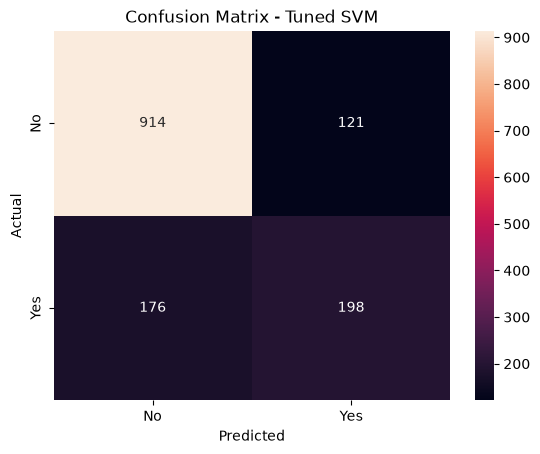

In [31]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned SVM')
plt.show()

### Confusion Matrix - Tuned SVM

The confusion matrix shows that the tuned SVM correctly classified 914 non-churned customers and 198 churned customers. The model incorrectly classified 121 non-churned customers as churned and 176 churned customers as non-churned.

The tuned model identified 198 out of 374 actual churned customers, resulting in a recall of 52.94%. Compared with the baseline SVM, the tuned model improved recall from 48.40% to 52.94% and F1-score from 55.18% to 57.14%.

### ROC-AUC (Receiver Operating Characteristic – Area Under the Curve)


In [32]:
y_score_tuned = best_model.decision_function(X_test)
y_score_tuned

array([-2.36497762,  0.84603991, -2.17925247, ..., -1.2051964 ,
       -2.12299872, -3.25966767], shape=(1409,))

- The SVM model doesn't just make a final prediction of 0 or 1.
- It can also calculate a decision score that tells us how strongly each sample is positioned toward one class or the other.
- If the value is negative, then the intepretation is slightly/strongly towards class 0 (bengin)
- If the value is positive, then the intepretation is slightly/strongly towards class 1 (phishing)

In [33]:
roc_auc_tuned = roc_auc_score(y_test, y_score_tuned)

print("ROC-AUC Score:", roc_auc_tuned)

ROC-AUC Score: 0.8272288098375056


### ROC-AUC Evaluation

The tuned SVM achieved a ROC-AUC score of 82.72%. This indicates that the model has good ability to distinguish between customers who churn and customers who do not churn based on the model's decision scores.

ROC-AUC provides an additional evaluation of the model's class discrimination beyond the classification metrics such as accuracy, precision, recall, and F1-score.

**Roughly**:

- Negative score → predicted No Churn
- Positive score → predicted Churn
- Score near 0 → close to the decision boundary

So the SVM needs some cut-off (threshold) to decide where Churn begins.

### Create ROC Curve

In [34]:
from sklearn.metrics import roc_curve

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_score_tuned)

In [36]:
fpr, tpr, thresholds

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.66183575e-04,
        9.66183575e-04, 1.93236715e-03, 1.93236715e-03, 2.89855072e-03,
        2.89855072e-03, 4.83091787e-03, 4.83091787e-03, 5.79710145e-03,
        5.79710145e-03, 7.72946860e-03, 7.72946860e-03, 8.69565217e-03,
        8.69565217e-03, 9.66183575e-03, 9.66183575e-03, 1.06280193e-02,
        1.06280193e-02, 1.15942029e-02, 1.15942029e-02, 1.25603865e-02,
        1.25603865e-02, 1.35265700e-02, 1.35265700e-02, 1.44927536e-02,
        1.44927536e-02, 1.54589372e-02, 1.54589372e-02, 1.64251208e-02,
        1.64251208e-02, 1.73913043e-02, 1.73913043e-02, 1.83574879e-02,
        1.83574879e-02, 2.02898551e-02, 2.02898551e-02, 2.22222222e-02,
        2.22222222e-02, 2.31884058e-02, 2.31884058e-02, 2.41545894e-02,
        2.41545894e-02, 2.70531401e-02, 2.70531401e-02, 2.89855072e-02,
        2.89855072e-02, 2.99516908e-02, 2.99516908e-02, 3.18840580e-02,
        3.18840580e-02, 3.57487923e-02, 3.57487923e-02, 3.671497

#### This calculates three things:
- fpr → False Positive Rate : How many actual non-churners wrongly called churners?
- tpr → True Positive Rate : How many actual churners found?
- thresholds → different decision thresholds used to create the curve : The model evaluates different decision thresholds and calculates the corresponding False Positive Rate (FPR) and True Positive Rate (TPR) at each threshold.

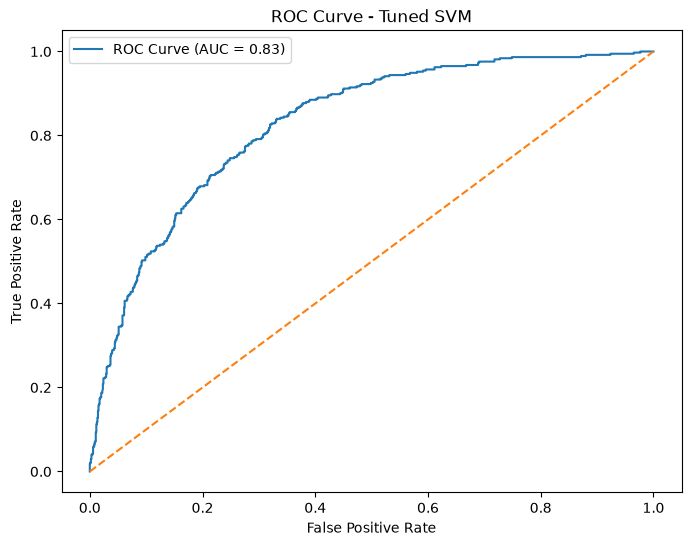

In [42]:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_tuned:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')  # this creates a diagonal dashed line from (0,0) to (1,1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned SVM')
plt.legend()

plt.show()

### ROC-AUC Findings

- The tuned SVM achieved a **ROC-AUC score of 0.83**.
- The ROC curve remains above the diagonal reference line, indicating that the model performs better than random classification.
- The model shows a good ability to distinguish between customers who **churn** and those who **do not churn**.
- The ROC curve reaches a relatively high True Positive Rate while maintaining a lower False Positive Rate in several regions.
- ROC-AUC provides an additional measure of model performance beyond accuracy, precision, recall, and F1-score.

### Save the tuned model

In [37]:
import joblib

In [38]:
joblib.dump(best_model, r"Model\best_model.joblib")

['Model\\best_model.joblib']